In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
import os

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#DataSet 1 (Health Care)
path_health = kagglehub.dataset_download("rabieelkharoua/chronic-kidney-disease-dataset-analysis")
print("Path to dataset files:", path_health)

#DataSet 2 (Marketing)
path_marketing = kagglehub.dataset_download("rodsaldanha/arketing-campaign")
print("Path to dataset files:", path_marketing)

#DataSet 3 (Energy)
path_energy = kagglehub.dataset_download("guillemservera/fuels-futures-data")
print("Path to dataset files:", path_energy)

#DataSet 4 (Telecom Data Set)
path_telecom = kagglehub.dataset_download("blastchar/telco-customer-churn")

#DataSet 5 (Bank)
path_bank = kagglehub.dataset_download("barelydedicated/bank-customer-churn-modeling")

#DataSet 6 (Internet)
path_internet = kagglehub.dataset_download("mehmetsabrikunt/internet-service-churn")

print("Path to dataset files:", path_bank)
files = os.listdir(path_internet)
print("Files in dataset folder:", files)

Path to dataset files: /home/codespace/.cache/kagglehub/datasets/rabieelkharoua/chronic-kidney-disease-dataset-analysis/versions/1
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/rodsaldanha/arketing-campaign/versions/8
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/guillemservera/fuels-futures-data/versions/191
Path to dataset files: /home/codespace/.cache/kagglehub/datasets/barelydedicated/bank-customer-churn-modeling/versions/1
Files in dataset folder: ['internet_service_churn.csv']


In [3]:
#Health Dataframe
path_to_file = os.path.join(path_health, "Chronic_Kidney_Dsease_data.csv")
df_health = pd.read_csv(path_to_file)

#Marketing Dataframe
path_to_file_two = os.path.join(path_marketing, "marketing_campaign.csv")
df_marketing = pd.read_csv(path_to_file_two, sep=";")

#Energy Dataframe
path_to_file_three = os.path.join(path_energy, "all_fuels_data.csv")
df_energy = pd.read_csv(path_to_file_three)

#Telecom Dataframe 
path_to_file_four = os.path.join(path_telecom, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_telecom = pd.read_csv(path_to_file_four)

#Bank Dataframe 
path_to_file_five = os.path.join(path_bank, "Churn_Modelling.csv")
df_bank = pd.read_csv(path_to_file_five)

#Internet Dataframe
path_to_file_six = os.path.join(path_internet, "internet_service_churn.csv")
df_internet = pd.read_csv(path_to_file_six)



In [4]:
#Telecom EDA
df_telecom.shape

(7043, 21)

In [5]:
df_telecom.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df_telecom.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
df_telecom.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

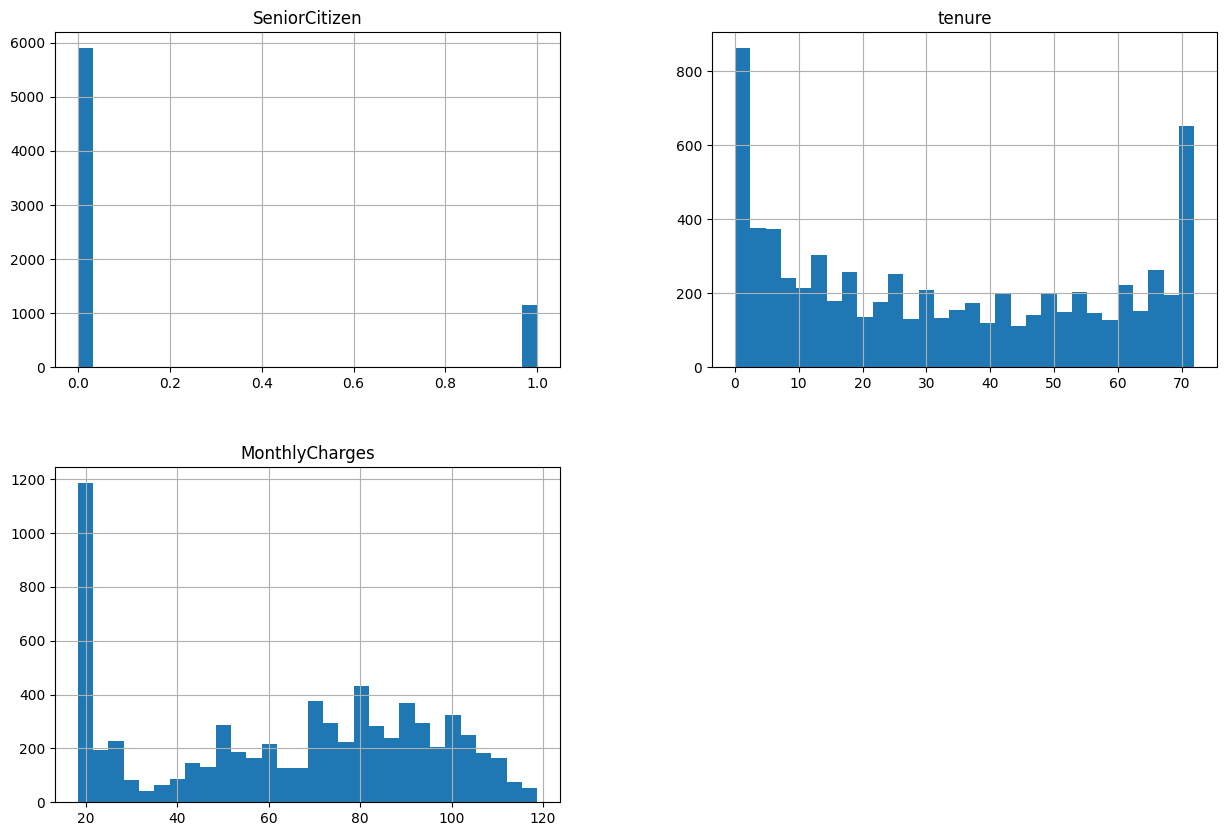

In [8]:
df_telecom.hist(bins=30, figsize=(15,10))
plt.show()

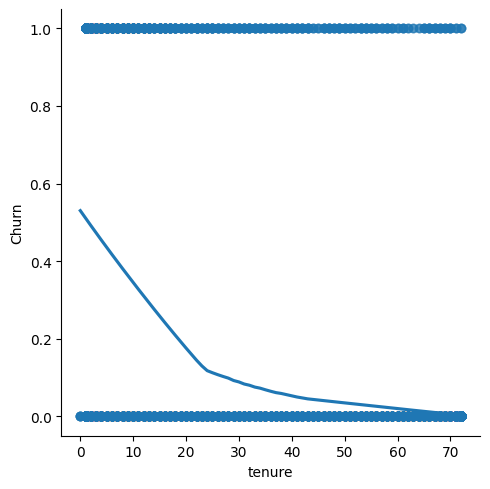

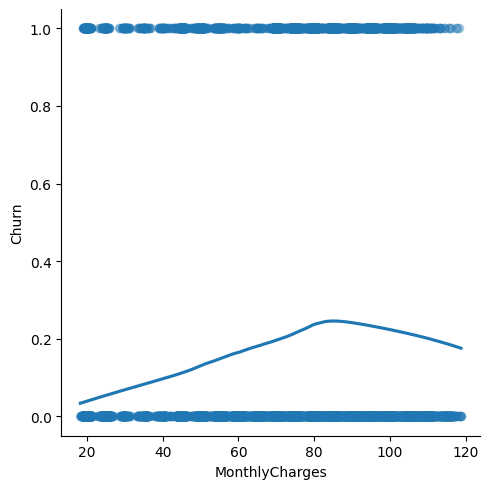

In [9]:
df_telecom['Churn'] = df_telecom['Churn'].map({'Yes': 1, 'No': 0})


sns.lmplot(data=df_telecom, x='tenure', y='Churn', lowess=True, scatter_kws={'alpha':0.3})
sns.lmplot(data=df_telecom, x='MonthlyCharges', y='Churn', lowess=True, scatter_kws={'alpha':0.3})


/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


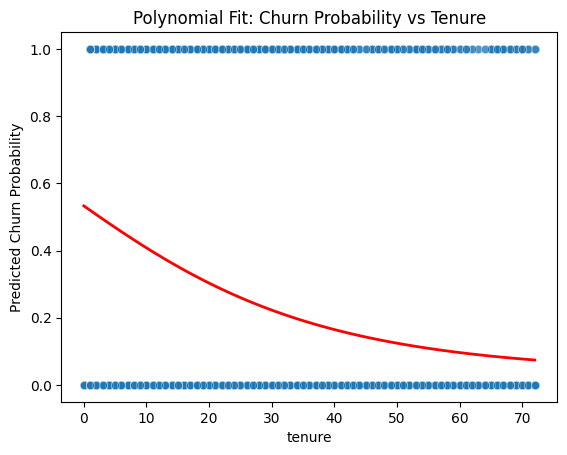

In [10]:
from sklearn.linear_model import LogisticRegression

# create polynomial feature
df_telecom['tenure_sq'] = df_telecom['tenure'] ** 2

# define X and y
X = df_telecom[['tenure', 'tenure_sq']]
y = df_telecom['Churn']

# fit logistic regression
log_reg_poly = LogisticRegression()
log_reg_poly.fit(X, y)

# generate predictions across the tenure range
tenure_range = np.linspace(df_telecom['tenure'].min(), df_telecom['tenure'].max(), 100)
tenure_sq_range = tenure_range ** 2
pred_prob = log_reg_poly.predict_proba(np.column_stack((tenure_range, tenure_sq_range)))[:, 1]

# plot actual data and predicted curve
sns.scatterplot(x='tenure', y='Churn', data=df_telecom, alpha=0.3)
plt.plot(tenure_range, pred_prob, color='red', linewidth=2)
plt.title('Polynomial Fit: Churn Probability vs Tenure')
plt.ylabel('Predicted Churn Probability')
plt.show()


/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


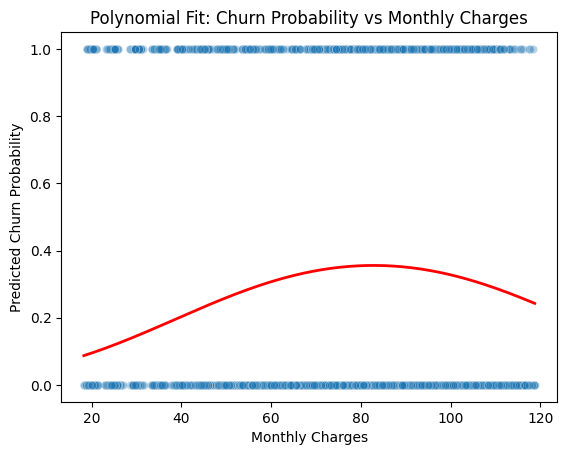

In [11]:

# create polynomial term
df_telecom['MonthlyCharges_sq'] = df_telecom['MonthlyCharges'] ** 2

# define X and y
X = df_telecom[['MonthlyCharges', 'MonthlyCharges_sq']]
y = df_telecom['Churn']

# fit logistic regression
log_reg_poly_mc = LogisticRegression(max_iter=1000)
log_reg_poly_mc.fit(X, y)

# generate predictions across MonthlyCharges range
charges_range = np.linspace(df_telecom['MonthlyCharges'].min(),
                            df_telecom['MonthlyCharges'].max(), 200)
charges_sq_range = charges_range ** 2
pred_prob_mc = log_reg_poly_mc.predict_proba(
    np.column_stack((charges_range, charges_sq_range))
)[:, 1]

# plot
sns.scatterplot(x='MonthlyCharges', y='Churn', data=df_telecom, alpha=0.3)
plt.plot(charges_range, pred_prob_mc, color='red', linewidth=2)
plt.title('Polynomial Fit: Churn Probability vs Monthly Charges')
plt.ylabel('Predicted Churn Probability')
plt.xlabel('Monthly Charges')
plt.show()


In [12]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Define X, y
X = df_telecom[['tenure', 'MonthlyCharges']]
y = df_telecom['Churn']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Polynomial features + scaling + ridge regularization
ridge_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scale', StandardScaler()),
    ('ridge', RidgeCV(alphas=[0.1, 1, 10]))
])

ridge_pipeline.fit(X_train, y_train)
y_pred = ridge_pipeline.predict(X_test)

print("Ridge ROC-AUC:", roc_auc_score(y_test, y_pred))


Ridge ROC-AUC: 0.8328731354870765


In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# Select predictors
X = df_telecom[['tenure', 'MonthlyCharges']]

# Create polynomial and interaction terms
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Get feature names
feature_names = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=feature_names)

# Standardize for numerical stability
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly_df)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_names)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_scaled_df.columns
vif_data['VIF'] = [variance_inflation_factor(X_scaled_df.values, i)
                   for i in range(X_scaled_df.shape[1])]
vif_data


,Feature,VIF
0,tenure,18.072061
1,MonthlyCharges,26.089665
2,tenure^2,16.684313
3,tenure MonthlyCharges,11.345871
4,MonthlyCharges^2,30.119113


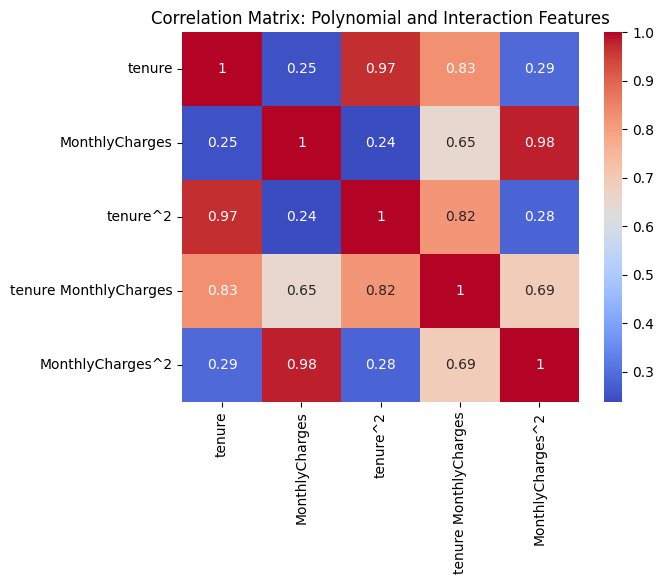

In [14]:

sns.heatmap(X_poly_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix: Polynomial and Interaction Features')
plt.show()


In [15]:
# ---------------------------------------------
# Variance Inflation Factor (VIF) - Telco Example
# Using existing df_telecom
# ---------------------------------------------

from sklearn.preprocessing import OneHotEncoder

# Select relevant columns
cols = ['StreamingTV', 'StreamingMovies', 'InternetService']
df_vif = df_telecom[cols].copy()

# Replace 'No internet service' with 'No' to simplify
df_vif = df_vif.replace('No internet service', 'No')

# Encode categorical features using one-hot encoding
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df_vif)
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(df_vif.columns))

# Calculate VIF for each encoded variable
vif_data = pd.DataFrame()
vif_data['Feature'] = encoded_df.columns
vif_data['VIF'] = [variance_inflation_factor(encoded_df.values, i) for i in range(encoded_df.shape[1])]

# Display VIF results sorted by magnitude
print(vif_data.sort_values('VIF', ascending=False))


                       Feature       VIF
0              StreamingTV_Yes  2.257024
1          StreamingMovies_Yes  2.246651
2  InternetService_Fiber optic  1.738657
3           InternetService_No  1.000000


In [16]:
# ---------------------------------------------
# Variance Inflation Factor (VIF) - Tenure, MonthlyCharges, Contract
# Using existing df_telecom
# ---------------------------------------------

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import OneHotEncoder

# Select relevant columns
cols = ['tenure', 'MonthlyCharges', 'Contract']
df_vif = df_telecom[cols].copy()

# Some datasets label tenure as lowercase "tenure"
if 'tenure' in df_vif.columns:
    df_vif.rename(columns={'tenure': 'tenure'}, inplace=True)

# Encode categorical feature 'Contract'
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded = encoder.fit_transform(df_vif[['Contract']])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Contract']))

# Combine with numeric features
X = pd.concat([df_vif[['tenure', 'MonthlyCharges']].reset_index(drop=True), encoded_df], axis=1)

# Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display results
print(vif_data.sort_values('VIF', ascending=False))


             Feature       VIF
0             tenure  6.006071
1     MonthlyCharges  2.825845
3  Contract_Two year  2.717134
2  Contract_One year  1.736881


In [17]:
# ---------------------------------------------
# Regularization to handle multicollinearity from polynomial features
# ---------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Example: predict MonthlyCharges from Tenure (and Tenure^2)
X = df_telecom[['tenure']]
y = df_telecom['MonthlyCharges']

# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---- Ridge Regression ----
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

# ---- Lasso Regression ----
lasso = Lasso(alpha=0.05)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)

# ---- Elastic Net ----
elastic = ElasticNet(alpha=0.05, l1_ratio=0.5)
elastic.fit(X_train_scaled, y_train)
elastic_pred = elastic.predict(X_test_scaled)

# Evaluate
for name, pred in [('Ridge', ridge_pred), ('Lasso', lasso_pred), ('ElasticNet', elastic_pred)]:
    print(f"{name} R²: {r2_score(y_test, pred):.3f} | MSE: {mean_squared_error(y_test, pred):.3f}")

# View coefficients for each model
coef_df = pd.DataFrame({
    'Feature': poly.get_feature_names_out(['tenure']),
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    'ElasticNet': elastic.coef_
})
print(coef_df)


Ridge R²: 0.049 | MSE: 860.885
Lasso R²: 0.049 | MSE: 860.838
ElasticNet R²: 0.049 | MSE: 860.800
    Feature     Ridge     Lasso  ElasticNet
0    tenure  8.409940  7.586086    6.354740
1  tenure^2 -0.801107 -0.000000    1.134501


In [18]:
# ---------------------------------------------
# Ridge, Lasso, Elastic Net to stabilize tenure and tenure^2
# ---------------------------------------------
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet


# Use tenure as X and churn (or any continuous proxy) as y
# If you don't have a numeric target yet, we'll just make a dummy one for demonstration
X = df_telecom[['tenure']].copy()
y = df_telecom['tenure'] + np.random.normal(0, 1, len(df_telecom))  # artificial y to fit regression

# Polynomial expansion (tenure and tenure^2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
poly_features = poly.get_feature_names_out(['tenure'])

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Fit models with moderate penalty
ridge = Ridge(alpha=10).fit(X_scaled, y)
lasso = Lasso(alpha=0.1).fit(X_scaled, y)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5).fit(X_scaled, y)

# Compare coefficients
coef_df = pd.DataFrame({
    'Feature': poly_features,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
    'ElasticNet': elastic.coef_
})
print(coef_df)


    Feature      Ridge      Lasso  ElasticNet
0    tenure  24.085243  24.449115   16.768518
1  tenure^2   0.443867   0.000000    7.121201


In [20]:
print(df_telecom.columns.tolist())


['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'tenure_sq', 'MonthlyCharges_sq']


In [21]:
# ==== Clean, split, and prep Telco churn (robust to Churn being 0/1 or Yes/No) ====
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

df = df_telecom.copy()

# 1) Normalize column names (strip spaces just in case)
df.columns = df.columns.str.strip()

# 2) Make sure Churn is numeric 0/1
if pd.api.types.is_numeric_dtype(df['Churn']):
    df['Churn'] = df['Churn'].astype(int)
else:
    df['Churn'] = (df['Churn'].astype(str).str.strip().str.lower()
                              .map({'yes':1,'no':0}))
# sanity check
assert df['Churn'].isna().sum() == 0, "Churn still has NaNs after normalization."

# 3) Common Telco gotcha: TotalCharges sometimes has blanks
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')

# 4) Build X, y and split
drop_cols = [c for c in ['customerID'] if c in df.columns]
X = df.drop(columns=['Churn'] + drop_cols)
y = df['Churn'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5) Preprocess: impute+scale numeric; impute+one-hot categorical
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
    ],
    remainder='drop'
)

print("Ready. y_train NaNs:", y_train.isna().sum(), "| y_test NaNs:", y_test.isna().sum())
print("Numeric cols:", num_cols[:8], "...")
print("Categorical cols:", cat_cols[:8], "...")


Ready. y_train NaNs: 0 | y_test NaNs: 0
Numeric cols: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'tenure_sq', 'MonthlyCharges_sq'] ...
Categorical cols: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup'] ...


In [22]:
# ---------- A) Stepwise selection on the preprocessed design ----------
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

# Build concrete design matrices once (so SFS has arrays to work on)
X_train_t = preprocess.fit_transform(X_train, y_train)
X_test_t  = preprocess.transform(X_test)

# Recover feature names (numeric + one-hot)
oh = preprocess.named_transformers_['cat']['oh'] if len(X_train.select_dtypes(include='object').columns) else None
cat_names = oh.get_feature_names_out(preprocess.transformers_[1][2]) if oh is not None else np.array([])
num_names = preprocess.transformers_[0][2] if len(preprocess.transformers_[0][2]) else []
feature_names = np.r_[num_names, cat_names]

# Base classifier
logit = LogisticRegression(max_iter=3000, solver='liblinear')

def run_sfs(direction, k):
    sfs = SequentialFeatureSelector(
        logit, n_features_to_select=k, direction=direction,
        scoring='roc_auc', cv=5, n_jobs=-1
    )
    sfs.fit(X_train_t, y_train)
    idx = sfs.get_support(indices=True)
    model = LogisticRegression(max_iter=3000, solver='liblinear')
    model.fit(X_train_t[:, idx], y_train)
    y_score = model.predict_proba(X_test_t[:, idx])[:, 1]
    auc = roc_auc_score(y_test, y_score)
    return auc, idx

# Try a few k values and keep the best for each direction
for k in [10, 20, 40]:
    auc_fwd, idx_fwd = run_sfs('forward', k)
    auc_bwd, idx_bwd = run_sfs('backward', k)
    print(f"[k={k:>2}]  Forward AUC={auc_fwd:.3f} | Backward AUC={auc_bwd:.3f}")

# Show details for the best forward/backward run you want to keep (e.g., k = 20)
k_keep = 20
auc_fwd, idx_fwd = run_sfs('forward', k_keep)
auc_bwd, idx_bwd = run_sfs('backward', k_keep)

print(f"\nFinal (k={k_keep})  Forward  ROC-AUC={auc_fwd:.3f}")
print("Forward selected features (first 15):", feature_names[idx_fwd][:15], "...")
print(f"\nFinal (k={k_keep})  Backward ROC-AUC={auc_bwd:.3f}")
print("Backward selected features (first 15):", feature_names[idx_bwd][:15], "...")


[k=10]  Forward AUC=0.841 | Backward AUC=0.840
[k=20]  Forward AUC=0.843 | Backward AUC=0.842
[k=40]  Forward AUC=0.843 | Backward AUC=0.843

Final (k=20)  Forward  ROC-AUC=0.843
Forward selected features (first 15): ['tenure' 'tenure_sq' 'Partner_Yes' 'Dependents_No' 'Dependents_Yes'
 'PhoneService_Yes' 'MultipleLines_No' 'MultipleLines_Yes'
 'InternetService_Fiber optic' 'OnlineSecurity_No' 'OnlineBackup_No'
 'TechSupport_No' 'StreamingTV_Yes' 'StreamingMovies_Yes'
 'Contract_Month-to-month'] ...

Final (k=20)  Backward ROC-AUC=0.842
Backward selected features (first 15): ['tenure' 'MonthlyCharges' 'tenure_sq' 'Partner_No' 'Dependents_No'
 'MultipleLines_Yes' 'InternetService_Fiber optic' 'OnlineSecurity_No'
 'DeviceProtection_No' 'DeviceProtection_No internet service'
 'TechSupport_No internet service' 'TechSupport_Yes' 'StreamingTV_No'
 'StreamingTV_No internet service' 'StreamingMovies_No internet service'] ...


In [23]:
# ---------- B) PCR: preprocess -> PCA -> Logistic ----------
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

def pcr_auc(n_components):
    pcr = Pipeline([
        ('prep', preprocess),
        ('pca', PCA(n_components=n_components)),
        ('clf', LogisticRegression(max_iter=3000, solver='liblinear'))
    ])
    pcr.fit(X_train, y_train)
    y_score = pcr.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, y_score)

for k in [5, 10, 20, 40]:
    print(f"PCR (n_components={k:>2}) ROC-AUC: {pcr_auc(k):.3f}")

# Optional: see how much variance PCs explain to pick k
pca_probe = Pipeline([('prep', preprocess), ('pca', PCA())]).fit(X_train, y_train)
cum_var = pca_probe.named_steps['pca'].explained_variance_ratio_.cumsum()
print("Cumulative variance, first 10 PCs:", np.round(cum_var[:10], 3))


PCR (n_components= 5) ROC-AUC: 0.830
PCR (n_components=10) ROC-AUC: 0.833
PCR (n_components=20) ROC-AUC: 0.834
PCR (n_components=40) ROC-AUC: 0.844
Cumulative variance, first 10 PCs: [0.316 0.508 0.579 0.641 0.68  0.715 0.749 0.779 0.803 0.826]


In [24]:
# ---------- C) PLSR: preprocess -> PLS -> ROC-AUC ----------
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

def pls_auc(n_components):
    pls = Pipeline([
        ('prep', preprocess),
        ('pls', PLSRegression(n_components=n_components))
    ])
    pls.fit(X_train, y_train)
    y_score = pls.predict(X_test).ravel()   # continuous scores -> ROC-AUC
    return roc_auc_score(y_test, y_score)

for k in [2, 5, 10, 20]:
    print(f"PLSR (n_components={k:>2}) ROC-AUC: {pls_auc(k):.3f}")


PLSR (n_components= 2) ROC-AUC: 0.827
PLSR (n_components= 5) ROC-AUC: 0.832
PLSR (n_components=10) ROC-AUC: 0.834
PLSR (n_components=20) ROC-AUC: 0.838


In [25]:
# After fitting a PCR model
pcr = Pipeline([
    ('prep', preprocess),
    ('pca', PCA(n_components=20)),
    ('clf', LogisticRegression(max_iter=3000, solver='liblinear'))
])
pcr.fit(X_train, y_train)

# Inspect coefficient magnitude balance
coefs = pcr.named_steps['clf'].coef_[0]
print("Mean absolute weight:", abs(coefs).mean())
print("Coefficient std dev:", np.std(coefs))


Mean absolute weight: 0.18736946636472387
Coefficient std dev: 0.26834825339240176


In [26]:

# Extract PCA components from the trained pipeline
pca = pcr.named_steps['pca']
corr_matrix = np.corrcoef(pca.components_)
print("Off-diagonal correlations (should be near 0):", np.mean(np.abs(corr_matrix - np.eye(len(corr_matrix)))))


Off-diagonal correlations (should be near 0): 0.0015074946154485292


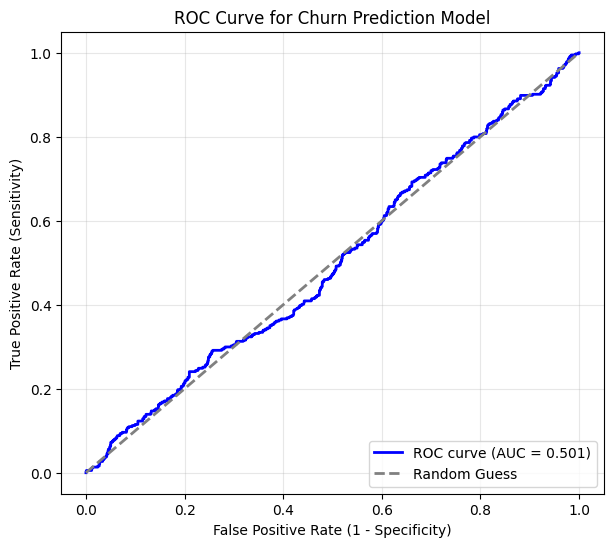

In [27]:
# --- ROC Curve Visualization ---
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Assuming you already have model predictions:
# y_test = your true labels (0/1 for churn)
# y_pred = model.predict_proba(X_test)[:, 1]  # predicted probabilities for churn

# Compute False Positive Rate (FPR) and True Positive Rate (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Compute the Area Under the Curve (AUC)
roc_auc = roc_auc_score(y_test, y_pred)

# --- Plot ---
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')

plt.title('ROC Curve for Churn Prediction Model')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [28]:
# --- WEEK 4: Logistic Regression + Feature Scaling (Telco) ---

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# If you already have df_telecom, X_train, X_test, y_train, y_test, and 'preprocess' defined, you can skip to the pipeline.fit()
df = df_telecom.copy()
df.columns = df.columns.str.strip()

# Target to 0/1 (robust if already numeric)
if pd.api.types.is_numeric_dtype(df['Churn']):
    df['Churn'] = df['Churn'].astype(int)
else:
    df['Churn'] = df['Churn'].astype(str).str.strip().str.lower().map({'yes':1,'no':0})

# Fix TotalCharges (Telco quirk)
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].astype(str).str.strip(), errors='coerce')

# Build X, y and split
drop_cols = [c for c in ['customerID'] if c in df.columns]
X = df.drop(columns=['Churn'] + drop_cols)
y = df['Churn'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Column groups
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()

# Preprocess:
# - Numeric: impute median + STANDARDIZE (feature scaling)
# - Categorical: impute mode + One-Hot
preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc', StandardScaler())]), num_cols),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
    ],
    remainder='drop'
)

# Logistic Regression (L2 = Ridge-style regularization)
logit_clf = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(max_iter=3000, solver='liblinear'))  # L2 by default
])

logit_clf.fit(X_train, y_train)
y_proba = logit_clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)

print(f"Logistic (scaled) ROC-AUC: {auc:.3f}")

# Optional quick report at 0.5 threshold
y_pred = (y_proba >= 0.5).astype(int)
print("\nClassification report @0.5:")
print(classification_report(y_test, y_pred, digits=3))
print("Confusion matrix @0.5:\n", confusion_matrix(y_test, y_pred))



Logistic (scaled) ROC-AUC: 0.844

Classification report @0.5:
              precision    recall  f1-score   support

           0      0.841     0.902     0.871      1035
           1      0.662     0.529     0.588       374

    accuracy                          0.803      1409
   macro avg      0.752     0.716     0.730      1409
weighted avg      0.794     0.803     0.796      1409

Confusion matrix @0.5:
 [[934 101]
 [176 198]]


In [29]:
from sklearn.linear_model import LogisticRegressionCV

# LogisticRegressionCV tunes C via CV using ROC-AUC
logit_cv = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegressionCV(
        Cs=10, cv=5, scoring='roc_auc', max_iter=3000, solver='liblinear'
    ))
])

logit_cv.fit(X_train, y_train)
y_proba_cv = logit_cv.predict_proba(X_test)[:, 1]
auc_cv = roc_auc_score(y_test, y_proba_cv)
print(f"Logistic (scaled, CV-tuned C) ROC-AUC: {auc_cv:.3f}")

# Best C found
best_C = logit_cv.named_steps['clf'].C_[0]
print("Best C (inverse of regularization strength):", best_C)


Logistic (scaled, CV-tuned C) ROC-AUC: 0.842
Best C (inverse of regularization strength): 1291.5496650148827


In [30]:
# Extract feature names after preprocessing
prep = logit_clf.named_steps['prep']
oh = prep.named_transformers_['cat']['oh'] if len(cat_cols) else None
cat_names = oh.get_feature_names_out(cat_cols) if oh is not None else np.array([])
feature_names = np.r_[num_cols, cat_names]

# Get coefficients from the fitted (non-CV) model
coef = logit_clf.named_steps['clf'].coef_[0]
odds = np.exp(coef)  # odds ratios

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coef': coef,
    'odds_ratio': odds
}).sort_values('odds_ratio', ascending=False)

print("\nTop positive churn drivers (odds ratios):")
print(coef_df.head(10).to_string(index=False))

print("\nTop negative churn drivers (protective, odds ratio < 1):")
print(coef_df.tail(10).sort_values('odds_ratio').to_string(index=False))



Top positive churn drivers (odds ratios):
                       feature     coef  odds_ratio
                     tenure_sq 1.138021    3.120586
       Contract_Month-to-month 0.698719    2.011175
             MonthlyCharges_sq 0.552598    1.737763
   InternetService_Fiber optic 0.546790    1.727699
PaymentMethod_Electronic check 0.177437    1.194152
               StreamingTV_Yes 0.164499    1.178803
           StreamingMovies_Yes 0.163129    1.177189
             OnlineSecurity_No 0.147840    1.159328
                TechSupport_No 0.117831    1.125054
             MultipleLines_Yes 0.101418    1.106739

Top negative churn drivers (protective, odds ratio < 1):
                             feature      coef  odds_ratio
                              tenure -1.669036    0.188429
                   Contract_Two year -1.009424    0.364429
                      MonthlyCharges -0.860162    0.423094
                 InternetService_DSL -0.589088    0.554833
                 PaperlessBillin

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np

# Linear SVM uses a linear hyperplane; we'll use decision_function scores for ROC-AUC
svm_linear = Pipeline([
    ('prep', preprocess),
    ('clf', LinearSVC(C=1.0, class_weight=None))  # hinge loss; C controls regularization (lower C = stronger reg)
])

svm_linear.fit(X_train, y_train)
# decision_function gives signed distance to hyperplane (good ranking score for ROC-AUC)
scores_linear = svm_linear.decision_function(X_test)
auc_linear = roc_auc_score(y_test, scores_linear)
print(f"Linear SVM (C=1.0) ROC-AUC: {auc_linear:.3f}")

# Support vectors are not exposed by LinearSVC, but you can estimate model complexity by C and performance.


Linear SVM (C=1.0) ROC-AUC: 0.839


In [33]:
from sklearn.svm import SVC

# RBF (Gaussian) kernel: non-linear, controlled by C (regularization) and gamma (inverse length scale)
svm_rbf = Pipeline([
    ('prep', preprocess),
    ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', probability=False))  # use decision_function for AUC
])
svm_rbf.fit(X_train, y_train)
scores_rbf = svm_rbf.decision_function(X_test)
auc_rbf = roc_auc_score(y_test, scores_rbf)
print(f"RBF SVM (C=1.0, gamma='scale') ROC-AUC: {auc_rbf:.3f}")

# Polynomial kernel: can capture interactions and curvature of specified degree
svm_poly = Pipeline([
    ('prep', preprocess),
    ('clf', SVC(kernel='poly', degree=3, C=1.0, coef0=1.0, gamma='scale'))
])
svm_poly.fit(X_train, y_train)
scores_poly = svm_poly.decision_function(X_test)
auc_poly = roc_auc_score(y_test, scores_poly)
print(f"Poly-3 SVM (C=1.0, degree=3) ROC-AUC: {auc_poly:.3f}")


RBF SVM (C=1.0, gamma='scale') ROC-AUC: 0.792
Poly-3 SVM (C=1.0, degree=3) ROC-AUC: 0.803


In [34]:
from sklearn.model_selection import GridSearchCV

# RBF grid: tune both C (regularization) and gamma (complexity)
rbf_grid = {
    'clf__C':     [0.1, 1, 3, 10],
    'clf__gamma': ['scale', 0.1, 0.03, 0.01]
}
svm_rbf_gs = Pipeline([
    ('prep', preprocess),
    ('clf', SVC(kernel='rbf'))
])
gs_rbf = GridSearchCV(
    svm_rbf_gs, rbf_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
gs_rbf.fit(X_train, y_train)
scores_rbf_gs = gs_rbf.decision_function(X_test)
auc_rbf_gs = roc_auc_score(y_test, scores_rbf_gs)
print("Best RBF params:", gs_rbf.best_params_)
print(f"RBF SVM (GridSearch) ROC-AUC: {auc_rbf_gs:.3f}")

# Linear SVM grid (C only)
lin_grid = {'clf__C': [0.1, 0.3, 1, 3, 10]}
svm_lin_gs = Pipeline([
    ('prep', preprocess),
    ('clf', LinearSVC())
])
gs_lin = GridSearchCV(
    svm_lin_gs, lin_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=0
)
gs_lin.fit(X_train, y_train)
scores_lin_gs = gs_lin.decision_function(X_test)
auc_lin_gs = roc_auc_score(y_test, scores_lin_gs)
print("Best Linear params:", gs_lin.best_params_)
print(f"Linear SVM (GridSearch) ROC-AUC: {auc_lin_gs:.3f}")


Best RBF params: {'clf__C': 0.1, 'clf__gamma': 0.01}
RBF SVM (GridSearch) ROC-AUC: 0.831
Best Linear params: {'clf__C': 10}
Linear SVM (GridSearch) ROC-AUC: 0.838


In [35]:
from sklearn.calibration import CalibratedClassifierCV

svm_rbf_uncal = Pipeline([('prep', preprocess), ('clf', SVC(kernel='rbf', C=gs_rbf.best_params_['clf__C'], gamma=gs_rbf.best_params_['clf__gamma']))])
svm_rbf_uncal.fit(X_train, y_train)

cal_svm = CalibratedClassifierCV(svm_rbf_uncal, method='isotonic', cv=5)
cal_svm.fit(X_train, y_train)
proba_cal = cal_svm.predict_proba(X_test)[:, 1]
auc_cal = roc_auc_score(y_test, proba_cal)
print(f"Calibrated RBF SVM (probas) ROC-AUC: {auc_cal:.3f}")


Calibrated RBF SVM (probas) ROC-AUC: 0.833


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Baseline tree (unpruned trees can overfit, so we start with limits)
tree = Pipeline([
    ('prep', preprocess),
    ('clf', DecisionTreeClassifier(
        random_state=42,
        max_depth=6,              # regularization: limit depth
        min_samples_leaf=50,      # regularization: minimum samples per leaf
        class_weight=None         # set to 'balanced' if class imbalance is large
    ))
])

tree.fit(X_train, y_train)
tree_auc = roc_auc_score(y_test, tree.predict_proba(X_test)[:,1])
print(f"Decision Tree ROC-AUC: {tree_auc:.3f}")

# Grid search to tune variance/bias tradeoff
param_grid = {
    'clf__max_depth': [4, 6, 8, 10],
    'clf__min_samples_leaf': [20, 50, 100],
    'clf__min_samples_split': [50, 100, 200]
}
tree_gs = GridSearchCV(tree, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
tree_gs.fit(X_train, y_train)
best_tree_auc = roc_auc_score(y_test, tree_gs.predict_proba(X_test)[:,1])
print("Best Tree params:", tree_gs.best_params_)
print(f"Decision Tree (GridSearch) ROC-AUC: {best_tree_auc:.3f}")

# ---- Feature importance (after preprocessing) ----
# Recover feature names from the ColumnTransformer
prep = tree_gs.best_estimator_.named_steps['prep']
num_cols = prep.transformers_[0][2]
oh = prep.named_transformers_['cat']['oh'] if len(prep.transformers_) > 1 else None
cat_cols = prep.transformers_[1][2] if len(prep.transformers_) > 1 else []
cat_names = oh.get_feature_names_out(cat_cols) if oh is not None else np.array([])
feature_names = np.r_[num_cols, cat_names]

importances = tree_gs.best_estimator_.named_steps['clf'].feature_importances_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
           .sort_values('importance', ascending=False)
print("\nTop 12 tree importances:")
print(imp_df.head(12).to_string(index=False))


Decision Tree ROC-AUC: 0.833
Best Tree params: {'clf__max_depth': 6, 'clf__min_samples_leaf': 50, 'clf__min_samples_split': 50}
Decision Tree (GridSearch) ROC-AUC: 0.833

Top 12 tree importances:
                       feature  importance
       Contract_Month-to-month    0.486274
   InternetService_Fiber optic    0.154464
                     tenure_sq    0.100259
                  TotalCharges    0.053227
                        tenure    0.045415
                MonthlyCharges    0.033916
PaymentMethod_Electronic check    0.027317
                TechSupport_No    0.022564
             OnlineSecurity_No    0.012954
             MonthlyCharges_sq    0.009749
             MultipleLines_Yes    0.008769
             Contract_Two year    0.008721


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ('prep', preprocess),
    ('clf', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,              # None = grow to purity; control with min_samples_* instead
        min_samples_leaf=20,
        max_features='sqrt',         # random subspace at each split (default for RF classification)
        oob_score=True,              # out-of-bag validation (bagging)
        n_jobs=-1,
        random_state=42
    ))
])

rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
print(f"Random Forest ROC-AUC: {rf_auc:.3f}")

# OOB score (on training bags’ held-out rows); rough generalization check
print("Random Forest OOB score (training holdout):", rf.named_steps['clf'].oob_score_)

# Grid/tune a few key knobs
rf_grid = {
    'clf__n_estimators': [200, 400],
    'clf__min_samples_leaf': [10, 20, 50],
    'clf__max_features': ['sqrt', 0.3, 0.5]
}
rf_gs = GridSearchCV(rf, rf_grid, cv=5, scoring='roc_auc', n_jobs=-1)
rf_gs.fit(X_train, y_train)
rf_gs_auc = roc_auc_score(y_test, rf_gs.predict_proba(X_test)[:,1])
print("Best RF params:", rf_gs.best_params_)
print(f"Random Forest (GridSearch) ROC-AUC: {rf_gs_auc:.3f}")

# ---- RF feature importance ----
prep = rf_gs.best_estimator_.named_steps['prep']
num_cols = prep.transformers_[0][2]
oh = prep.named_transformers_['cat']['oh'] if len(prep.transformers_) > 1 else None
cat_cols = prep.transformers_[1][2] if len(prep.transformers_) > 1 else []
cat_names = oh.get_feature_names_out(cat_cols) if oh is not None else np.array([])
feature_names = np.r_[num_cols, cat_names]

rf_imp = rf_gs.best_estimator_.named_steps['clf'].feature_importances_
rf_imp_df = pd.DataFrame({'feature': feature_names, 'importance': rf_imp}) \
             .sort_values('importance', ascending=False)
print("\nTop 12 RF importances:")
print(rf_imp_df.head(12).to_string(index=False))


Random Forest ROC-AUC: 0.845
Random Forest OOB score (training holdout): 0.8024494142705005
Best RF params: {'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 20, 'clf__n_estimators': 400}
Random Forest (GridSearch) ROC-AUC: 0.845

Top 12 RF importances:
                       feature  importance
       Contract_Month-to-month    0.124541
                     tenure_sq    0.106571
                        tenure    0.105453
                  TotalCharges    0.077472
             OnlineSecurity_No    0.065134
   InternetService_Fiber optic    0.059902
                TechSupport_No    0.051362
                MonthlyCharges    0.050290
             MonthlyCharges_sq    0.049546
PaymentMethod_Electronic check    0.042105
             Contract_Two year    0.033087
               OnlineBackup_No    0.021344


In [31]:
#Banking EDA
df_bank.shape

(10000, 14)

In [10]:
df_bank.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df_bank.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [12]:
df_bank.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

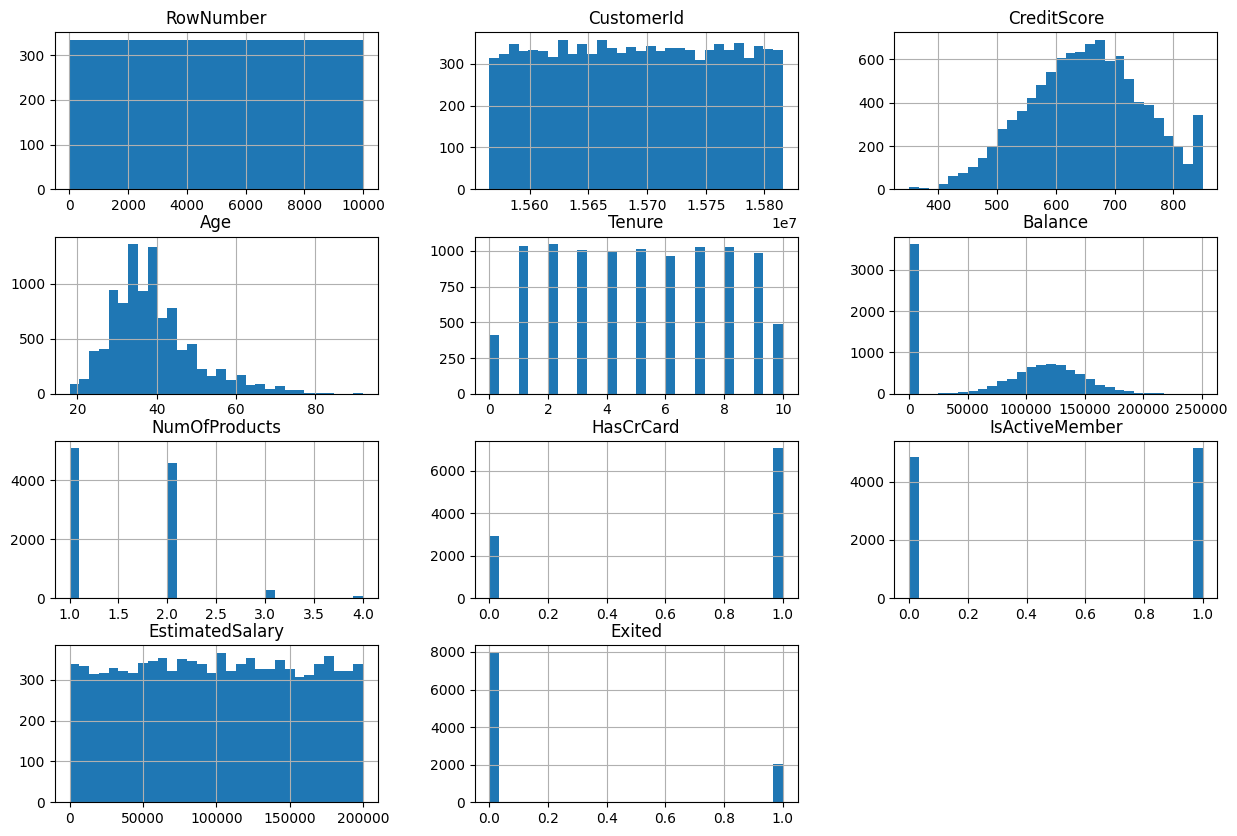

In [13]:
df_bank.hist(bins=30, figsize=(15,10))
plt.show()

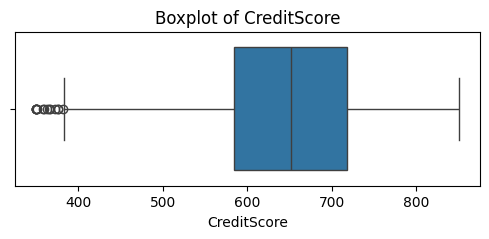

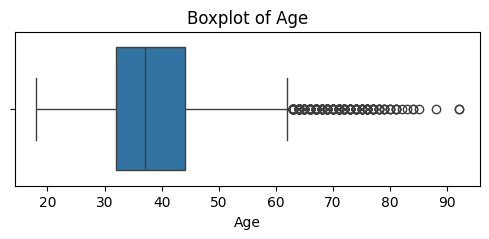

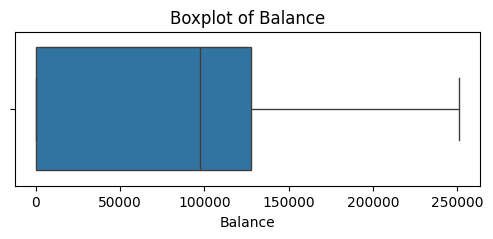

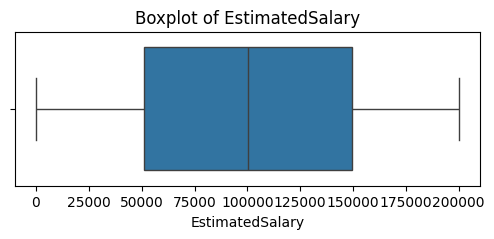

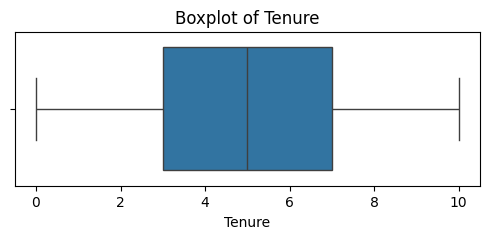

In [14]:
numeric_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Tenure']

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df_bank[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


In [15]:
#EDA of Internet 
df_internet.shape

(72274, 11)

In [16]:
df_internet.head()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1


In [17]:
df_internet.describe()

,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,reamining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
count,7.227400e+04,72274.000000,72274.000000,72274.000000,72274.000000,50702.000000,72274.000000,71893.000000,71893.000000,72274.000000,72274.000000
mean,8.463182e+05,0.815259,0.334629,2.450051,18.942483,0.716039,0.274234,43.689911,4.192076,0.207613,0.554141
std,4.891022e+05,0.388090,0.471864,2.034990,13.215386,0.697102,0.816621,63.405963,9.818896,0.997123,0.497064
min,1.500000e+01,0.000000,0.000000,-0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.222165e+05,1.000000,0.000000,0.930000,13.000000,0.000000,0.000000,6.700000,0.500000,0.000000,0.000000
50%,8.477840e+05,1.000000,0.000000,1.980000,19.000000,0.570000,0.000000,27.800000,2.100000,0.000000,1.000000
75%,1.269562e+06,1.000000,1.000000,3.300000,22.000000,1.310000,0.000000,60.500000,4.800000,0.000000,1.000000
max,1.689744e+06,1.000000,1.000000,12.800000,406.000000,2.920000,19.000000,4415.200000,453.300000,7.000000,1.000000


In [18]:
df_internet.dtypes

id                               int64
is_tv_subscriber                 int64
is_movie_package_subscriber      int64
subscription_age               float64
bill_avg                         int64
reamining_contract             float64
service_failure_count            int64
download_avg                   float64
upload_avg                     float64
download_over_limit              int64
churn                            int64
dtype: object

In [24]:
df_internet.isna().sum()

id                                 0
is_tv_subscriber                   0
is_movie_package_subscriber        0
subscription_age                   0
bill_avg                           0
reamining_contract             21572
service_failure_count              0
download_avg                     381
upload_avg                       381
download_over_limit                0
churn                              0
dtype: int64

In [ ]:
import matplotlib.pyplot as plt

sns.scatterplot(data=df_internet, x='MonthlyCharges', y='TotalCharges', alpha=0.4)
plt.title('Linear relationship: Monthly vs Total Charges')
plt.show()


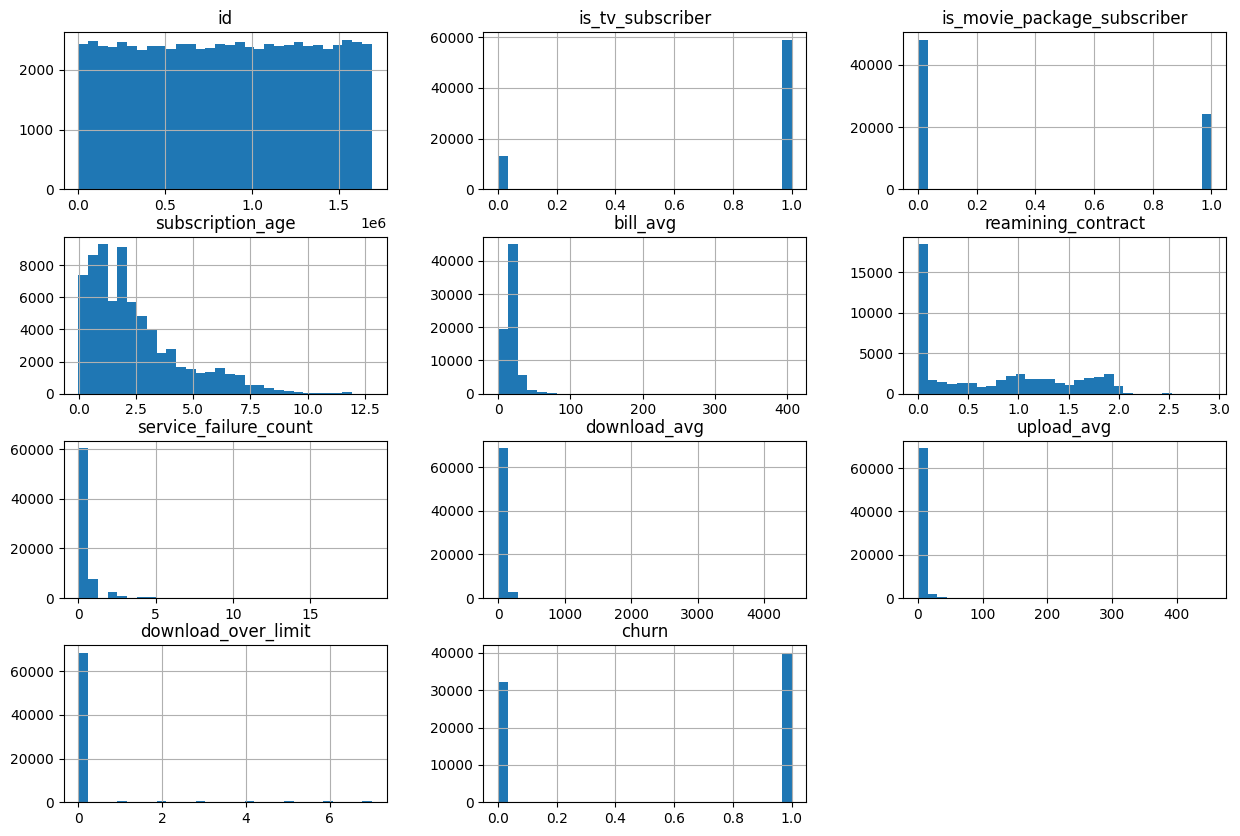

In [19]:
df_internet.hist(bins=30, figsize=(15,10))
plt.show()

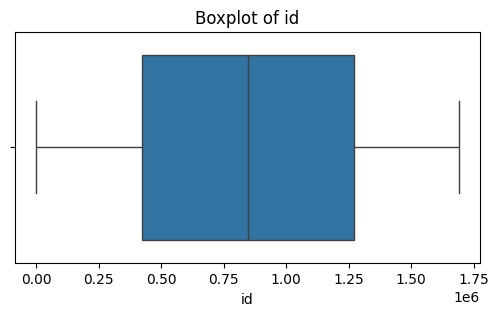

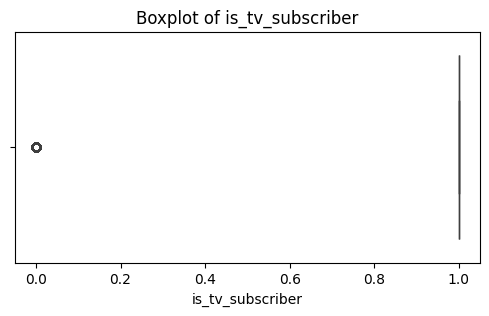

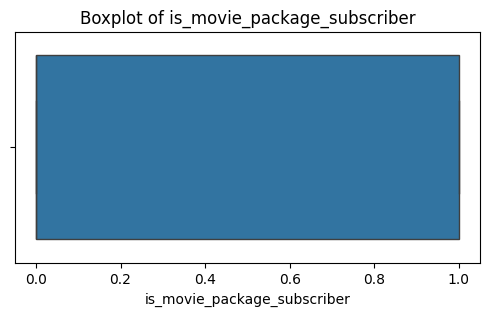

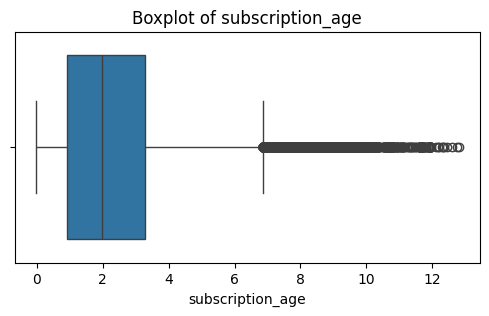

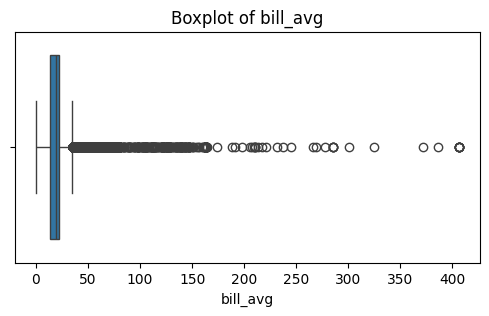

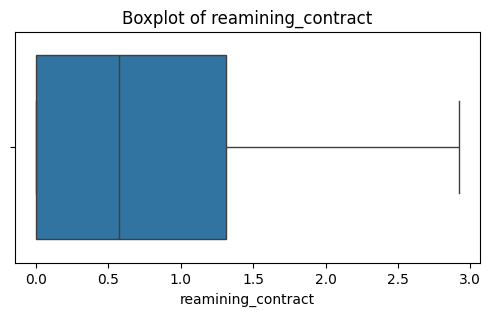

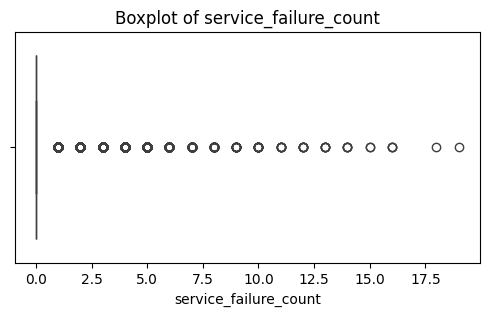

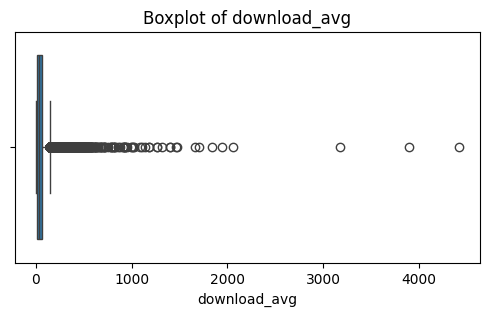

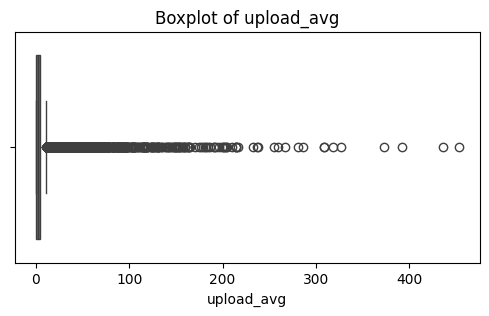

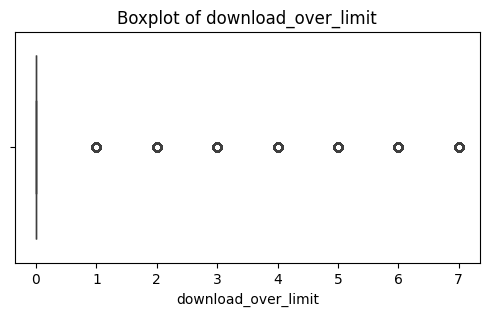

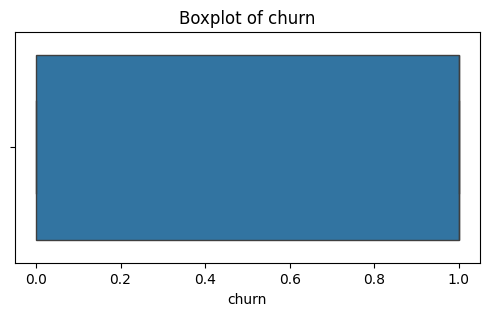

In [20]:
numeric_cols = df_internet.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df_internet[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [21]:
import statsmodels.api as sm

# Internet OLS Regression 
df_X = df_internet[['subscription_age', 'bill_avg']].copy()

df_X_poly = pd.concat([
    df_X,
    (df_X['subscription_age']**2).rename('subscription_age_sq'),
    (df_X['bill_avg']**2).rename('bill_avg_sq')
], axis=1)

# Create Interaction 
df_X_poly['age_bill_interaction'] = df_X['subscription_age'] * df_X['bill_avg']

# Target
y_true = df_internet['churn']

# Constant
df_X_poly = sm.add_constant(df_X_poly)

# Regression 
model = sm.OLS(y_true, df_X_poly)
results = model.fit()

print(results.summary())


                            OLS Regression Results                            
Dep. Variable:                  churn   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.028
Method:                 Least Squares   F-statistic:                     424.3
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        21:38:40   Log-Likelihood:                -50984.
No. Observations:               72274   AIC:                         1.020e+05
Df Residuals:                   72268   BIC:                         1.020e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    0.5539 

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Variance Inflation Factor (VIF)
X = df_X_poly.drop(columns=['const'])

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)


                feature        VIF
0      subscription_age  13.432928
1              bill_avg   5.077042
2   subscription_age_sq   9.720244
3           bill_avg_sq   2.064367
4  age_bill_interaction   6.130232


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Week 2 Prep

# Features
X = df_internet[['subscription_age', 'bill_avg']].copy()

# polynomial & interaction terms
X['subscription_age_sq'] = X['subscription_age']**2
X['bill_avg_sq'] = X['bill_avg']**2
X['age_bill_interaction'] = X['subscription_age'] * X['bill_avg']

# Target
y = df_internet['churn']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize features 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [25]:
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score, roc_auc_score

# Ridge

ridge = Ridge(alpha=1.0)  
ridge.fit(X_train_scaled, y_train)

print("Ridge coefficients:", ridge.coef_)
print("Ridge R^2 (train):", ridge.score(X_train_scaled, y_train))
print("Ridge R^2 (test):", ridge.score(X_test_scaled, y_test))


Ridge coefficients: [ 0.09493106 -0.00597052 -0.15438272  0.00857752 -0.01638581]
Ridge R^2 (train): 0.02788709222405661
Ridge R^2 (test): 0.029836076748897544


In [26]:
from sklearn.linear_model import Lasso

# Lasso

lasso = Lasso(alpha=0.001)  
lasso.fit(X_train_scaled, y_train)

print("Lasso coefficients:", lasso.coef_)
print("Non-zero features:", sum(lasso.coef_ != 0))


Lasso coefficients: [ 0.07547999 -0.00380985 -0.13850157  0.00409707 -0.01158747]
Non-zero features: 5


In [27]:
from sklearn.linear_model import ElasticNet

# Elastic Net

elastic = ElasticNet(alpha=0.001, l1_ratio=0.5) 
elastic.fit(X_train_scaled, y_train)

print("Elastic Net coefficients:", elastic.coef_)


Elastic Net coefficients: [ 0.08424121 -0.00490174 -0.14554432  0.00629924 -0.01387337]


In [28]:
from sklearn.model_selection import train_test_split, KFold, RepeatedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, roc_auc_score
from sklearn.linear_model import LinearRegression, LogisticRegression

 # Week 3
num_cols = [
    'subscription_age','bill_avg','reamining_contract','service_failure_count',
    'download_avg','upload_avg','is_tv_subscriber','is_movie_package_subscriber',
    'download_over_limit'
]

df = df_internet.dropna(subset=['churn']).copy()
X = df[num_cols].copy()
y = df['churn'].astype(int)

# train test 
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# impute and scale 
preproc = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])


rmse_scorer = make_scorer(lambda yt, yp: mean_squared_error(yt, yp, squared=False), greater_is_better=False)
cv5 = KFold(n_splits=5, shuffle=True, random_state=42)


In [29]:
from sklearn.feature_selection import SequentialFeatureSelector

# estimator 
est = LinearRegression()

# pipeline 
from sklearn.pipeline import make_pipeline
pipe = make_pipeline(preproc, est)

# forward and backward 
results = []
for k in range(1, len(num_cols)):  
    # Forward
    fsel = SequentialFeatureSelector(est, n_features_to_select=k,
                                     direction='forward', cv=cv5, scoring='r2', n_jobs=-1)
    fpipe = make_pipeline(preproc, fsel, est)
    r2 = cross_val_score(fpipe, X, y, cv=cv5, scoring='r2', n_jobs=-1).mean()
    rmse = -cross_val_score(fpipe, X, y, cv=cv5, scoring=rmse_scorer, n_jobs=-1).mean()
    results.append(('forward', k, r2, rmse))

    # Backward
    bsel = SequentialFeatureSelector(est, n_features_to_select=k,
                                     direction='backward', cv=cv5, scoring='r2', n_jobs=-1)
    bpipe = make_pipeline(preproc, bsel, est)
    r2b = cross_val_score(bpipe, X, y, cv=cv5, scoring='r2', n_jobs=-1).mean()
    rmseb = -cross_val_score(bpipe, X, y, cv=cv5, scoring=rmse_scorer, n_jobs=-1).mean()
    results.append(('backward', k, r2b, rmseb))

# best
best = sorted(results, key=lambda t: t[2], reverse=True)[:5]
best


/home/codespace/.local/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:971: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 152, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2159/1083749571.py", line 30, in <lambda>
  File "/home/codespace/.local/lib/python3.12/site-packages/sklearn/utils/_param_validation.py", line 196, in wrapper
    params = func_sig.bind(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/python/3.12.1/lib/python3.12/inspect

[('forward', 8, np.float64(0.4340532386481503), np.float64(nan)),
 ('backward', 8, np.float64(0.4340532386481503), np.float64(nan)),
 ('forward', 7, np.float64(0.4334909958338649), np.float64(nan)),
 ('backward', 7, np.float64(0.4334909958338649), np.float64(nan)),
 ('forward', 6, np.float64(0.4302506386072446), np.float64(nan))]

In [30]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

# Principal Component Analysis 
pcr = Pipeline([
    ('pre', preproc),
    ('pca', PCA()),
    ('ols', LinearRegression())
])

param_grid = {'pca__n_components': list(range(1, len(num_cols)+1))}
gs_pcr = GridSearchCV(pcr, param_grid, cv=cv5, scoring='r2', n_jobs=-1)
gs_pcr.fit(X, y)

print("Best PCR components:", gs_pcr.best_params_['pca__n_components'])
print("Best PCR CV R²:", gs_pcr.best_score_)


Best PCR components: 9
Best PCR CV R²: 0.43411888093529294


In [31]:
from sklearn.cross_decomposition import PLSRegression

# PLS Regression  
pls = Pipeline([
    ('pre', preproc),
    ('pls', PLSRegression())
])

param_grid = {'pls__n_components': list(range(1, min(len(num_cols), 10)+1))}
gs_pls = GridSearchCV(pls, param_grid, cv=cv5, scoring='r2', n_jobs=-1)
gs_pls.fit(X, y)

print("Best PLS components:", gs_pls.best_params_['pls__n_components'])
print("Best PLS CV R²:", gs_pls.best_score_)


Best PLS components: 4
Best PLS CV R²: 0.4341617948473077


In [32]:
# Week 4 Features and target
X = df_internet[num_cols].copy()
y = df_internet['churn'].astype(int)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [33]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [34]:
# split features continuous vs binary
cont_cols = [
    'subscription_age','bill_avg','reamining_contract',
    'service_failure_count','download_avg','upload_avg'
]
bin_cols = ['is_tv_subscriber','is_movie_package_subscriber','download_over_limit']

X = df_internet[cont_cols + bin_cols].copy()
y = df_internet['churn'].astype(int)

# Preprocessors
cont_pre = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])
bin_pre = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent'))
])

preproc = ColumnTransformer([
    ('cont', cont_pre, cont_cols),
    ('bin',  bin_pre,  bin_cols)
])

# Full pipeline
clf = Pipeline([
    ('prep', preproc),
    ('logit', LogisticRegression(max_iter=1000, solver='liblinear'))
])

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# fit
clf.fit(X_train, y_train)


,steps,"[('prep', ...), ('logit', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cont', ...), ('bin', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [35]:
# features 
feature_names = cont_cols + bin_cols

# coefficients
coefs = clf.named_steps['logit'].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)


                       Feature  Coefficient
8          download_over_limit     0.603192
1                     bill_avg     0.219901
3        service_failure_count     0.108036
5                   upload_avg    -0.012316
7  is_movie_package_subscriber    -0.312017
0             subscription_age    -0.333051
4                 download_avg    -1.005336
2           reamining_contract    -1.553945
6             is_tv_subscriber    -1.884609


In [36]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(clf, X, y, cv=5, scoring='roc_auc')

print("CV ROC-AUC mean:", cv_scores.mean())
print("CV ROC-AUC std :", cv_scores.std())


CV ROC-AUC mean: 0.8849117431339923
CV ROC-AUC std : 0.02495364998161915


Test ROC-AUC: 0.902
Test Accuracy: 0.836

Classification report:
              precision    recall  f1-score   support

           0      0.843     0.776     0.808      9668
           1      0.830     0.884     0.856     12015

    accuracy                          0.836     21683
   macro avg      0.837     0.830     0.832     21683
weighted avg      0.836     0.836     0.835     21683



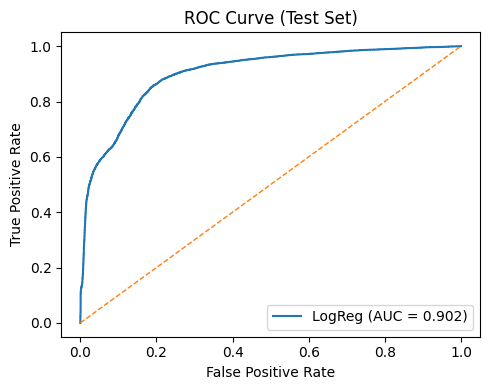

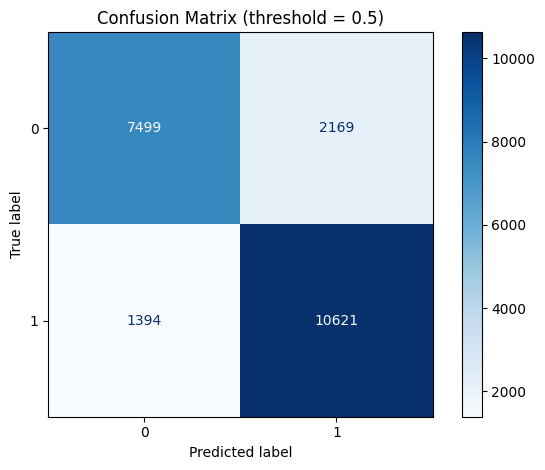

In [37]:
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score
)

# Prediction
y_prob = clf.predict_proba(X_test)[:, 1]   
y_pred = clf.predict(X_test)               

# Scalar
auc = roc_auc_score(y_test, y_prob)
acc = accuracy_score(y_test, y_pred)
print(f"Test ROC-AUC: {auc:.3f}")
print(f"Test Accuracy: {acc:.3f}\n")

print("Classification report:")
print(classification_report(y_test, y_pred, digits=3))

# ROC
fpr, tpr, thr = roc_curve(y_test, y_prob)
plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f'LogReg (AUC = {auc:.3f})')
plt.plot([0,1],[0,1],'--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Test Set)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Confusion 
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[0,1])
disp.plot(values_format='d', cmap='Blues')
plt.title('Confusion Matrix (threshold = 0.5)')
plt.tight_layout()
plt.show()



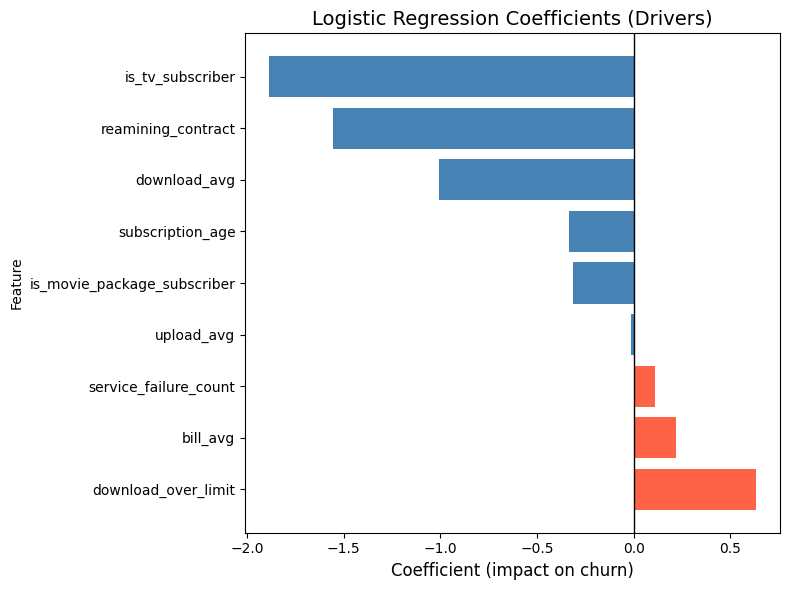

In [38]:

# Coefficients from log reg
coef_df = pd.DataFrame({
    "Feature": [
        "download_over_limit", "bill_avg", "service_failure_count", "upload_avg",
        "is_movie_package_subscriber", "subscription_age", "download_avg",
        "reamining_contract", "is_tv_subscriber"
    ],
    "Coefficient": [
        0.63192, 0.21991, 0.10836, -0.012316,
        -0.312017, -0.333851, -1.005336,
        -1.553945, -1.884609
    ]
})

# Coefficient sort 
coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

plt.figure(figsize=(8,6))
bars = plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=["tomato" if c>0 else "steelblue" for c in coef_df["Coefficient"]])
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients (Drivers)", fontsize=14)
plt.xlabel("Coefficient (impact on churn)", fontsize=12)
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


I put in a bar chart to show some of the best predictors for whether or not a customer will turnaway or churn from their internet contract / provider. The highest contributor was going over the download limit, along with the average bill and failure of service which makes sense as to why someone might want to switch. On the other hand, customers who had packaged services like TV/Movies or longer contracts would be less likely to churn away from the service. I used the standard scaler on continous features along witha columnn transformer in my pipeline with the target variable churn encoded as 0/1. I also evaluated the model with a 5-fold cross-validation and on the test set I had a ROC-AUC of .902 with a test accuracy of .836. To make this better I will look to regularization tuning using different C values in the logistic regression.   